<a href="https://colab.research.google.com/github/ghadisaedi/ghadi/blob/main/lab5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

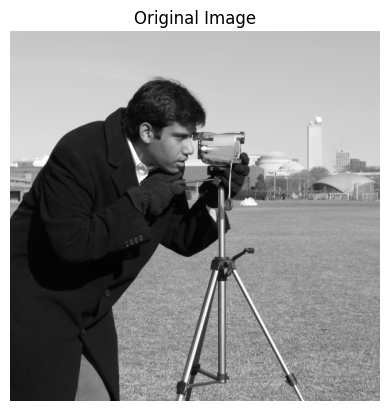

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, util
from scipy.ndimage import uniform_filter, median_filter, generic_filter

img = data.camera().astype(np.float32) / 255.0

def mse(a, b):
    return float(np.mean((a - b) ** 2))

plt.imshow(img, cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.show()

Gaussian noisy MSE: 0.005970281083136797


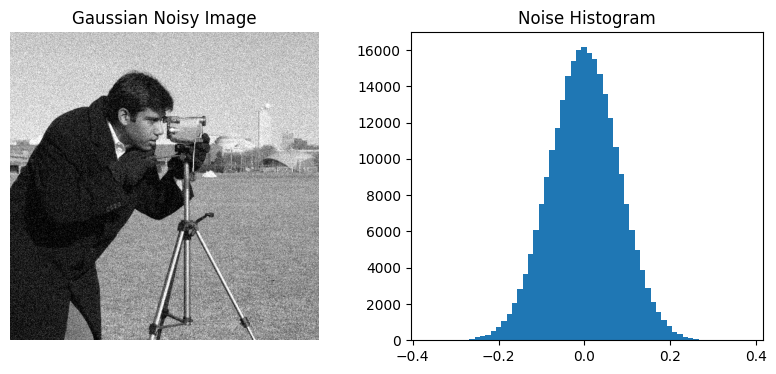

In [7]:
rng = np.random.default_rng(0)
sigma = 0.08
noise = rng.normal(0, sigma, img.shape).astype(np.float32)
g = np.clip(img + noise, 0, 1)

print("Gaussian noisy MSE:", mse(img, g))

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(g, cmap="gray")
plt.title("Gaussian Noisy Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.hist(noise.flatten(), bins=60)
plt.title("Noise Histogram")

plt.show()

Mean filter MSE: 0.0018401173874735832


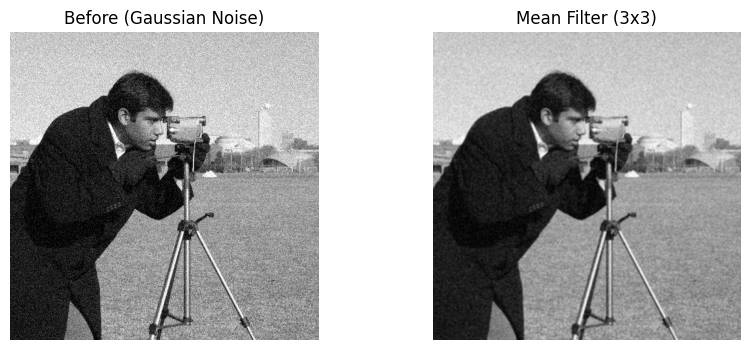

In [8]:
mean3 = uniform_filter(g, size=3)

print("Mean filter MSE:", mse(img, mean3))

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(g, cmap="gray")
plt.title("Before (Gaussian Noise)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mean3, cmap="gray")
plt.title("Mean Filter (3x3)")
plt.axis("off")

plt.show()

Geometric mean MSE: 0.0030262174550443888


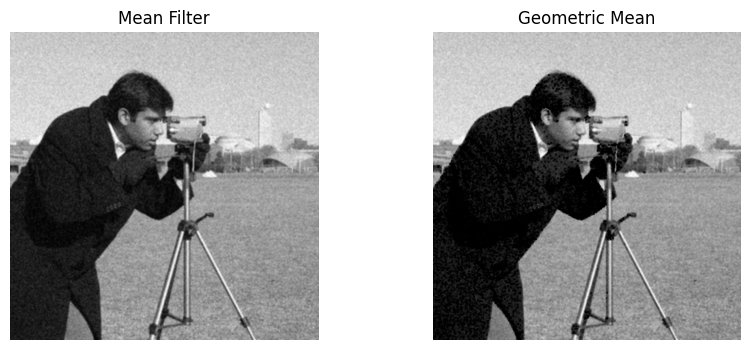

In [9]:
def geometric_mean_filter(im, size=3, eps=1e-6):
    im2 = np.clip(im, eps, 1.0)
    log_im = np.log(im2)
    m = uniform_filter(log_im, size=size)
    return np.exp(m)

geo3 = geometric_mean_filter(g, size=3)

print("Geometric mean MSE:", mse(img, geo3))

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(mean3, cmap="gray")
plt.title("Mean Filter")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(geo3, cmap="gray")
plt.title("Geometric Mean")
plt.axis("off")

plt.show()

Impulse noisy MSE: 0.026350151747465134


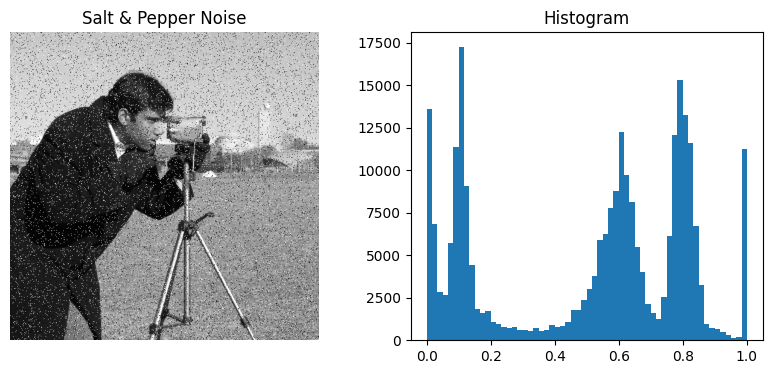

In [10]:
sp = util.random_noise(img, mode="s&p", amount=0.08).astype(np.float32)

print("Impulse noisy MSE:", mse(img, sp))

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(sp, cmap="gray")
plt.title("Salt & Pepper Noise")
plt.axis("off")

plt.subplot(1,2,2)
plt.hist(sp.flatten(), bins=60)
plt.title("Histogram")

plt.show()

Median filter MSE: 0.0010391906835138798


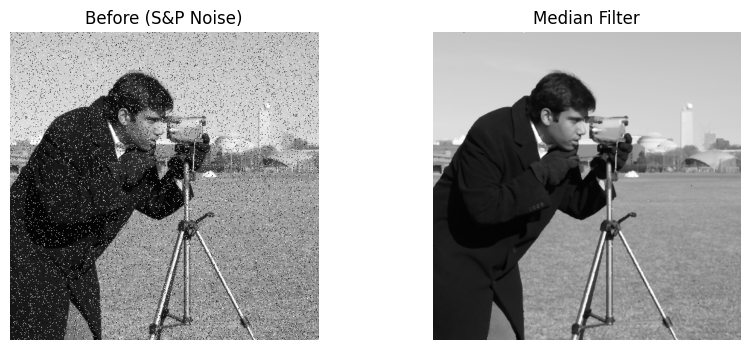

In [11]:
med3 = median_filter(sp, size=3)

print("Median filter MSE:", mse(img, med3))

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(sp, cmap="gray")
plt.title("Before (S&P Noise)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(med3, cmap="gray")
plt.title("Median Filter")
plt.axis("off")

plt.show()

Contraharmonic (Q=1.5) MSE: 0.05502324923872948
Contraharmonic (Q=-1.5) MSE: 0.10445006936788559


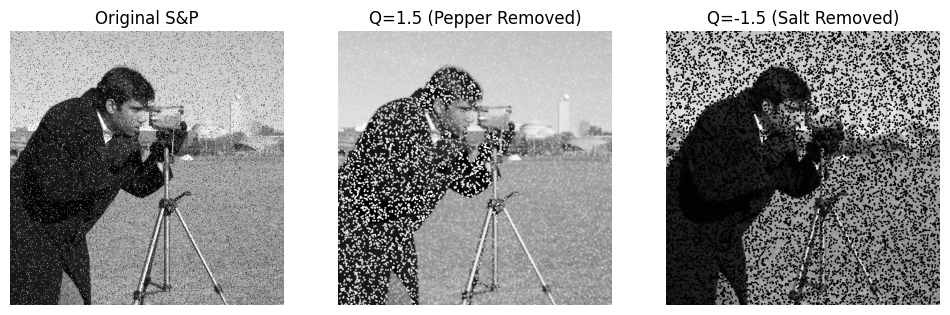

In [12]:
def contraharmonic(im, size=3, Q=1.5, eps=1e-6):
    def f(window):
        w = np.array(window, dtype=np.float32)
        num = np.sum((w + eps) ** (Q + 1))
        den = np.sum((w + eps) ** Q)
        return num / (den + eps)
    return generic_filter(im, f, size=size)

pepper_fixed = contraharmonic(sp, size=3, Q=1.5)
salt_fixed = contraharmonic(sp, size=3, Q=-1.5)

print("Contraharmonic (Q=1.5) MSE:", mse(img, pepper_fixed))
print("Contraharmonic (Q=-1.5) MSE:", mse(img, salt_fixed))

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(sp, cmap="gray")
plt.title("Original S&P")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(pepper_fixed, cmap="gray")
plt.title("Q=1.5 (Pepper Removed)")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(salt_fixed, cmap="gray")
plt.title("Q=-1.5 (Salt Removed)")
plt.axis("off")

plt.show()

**Reflect** **Q**

1. Why is restoration more objective than enhancement?
Because restoration uses mathematical models to recover the original image, while enhancement depends on visual preference.

2. Why must noise models be identified before restoration?
Because each noise type requires a specific filter, and using the wrong one can degrade the image.

3. Why is there no single best denoising filter?
Because noise varies, and each filter has trade-offs between noise removal and detail preservation.